# Testy statystyczne dla cech zbioru

Cel notebooka:
- Wczytanie i przygotowanie zbioru
- Wybór cech do testów

In [1]:
from src.data_loader import load_data
from src.preprocessing import prepare_data
from src.feature_statistical_tests import (
    compare_feature_between_classes
)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.style.use('default')  # reset stylu
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [2]:
# LOAD
df = load_data("../Dataset/WineQT.csv")

# BINARY MODE
X, y = prepare_data(df, mode="binary")
df = df.drop(["Id"], axis=1)

df["quality"] = y

Rozkład klas (po połączeniu klas):
quality
6    621
5    522
Name: count, dtype: int64


In [3]:
# TESTED FEATURES

features = [
    "alcohol",
    "sulphates",
    "volatile acidity"
]


===== FEATURE: alcohol =====

Class 5
count    522.000000
mean       9.922510
std        0.777469
min        8.400000
25%        9.400000
50%        9.700000
75%       10.300000
max       14.900000
Name: alcohol, dtype: float64

Class 6
count    621.000000
mean      10.878878
std        1.109438
min        8.400000
25%       10.000000
50%       10.800000
75%       11.700000
max       14.000000
Name: alcohol, dtype: float64

===== SHAPIRO-WILK =====
Class 5: stat=0.8514, p=9.1466e-22
Class 6: stat=0.9775, p=3.5857e-08

===== LEVENE =====
stat=98.0234, p=3.1576e-22

===== WELCH T-TEST =====
stat=-17.0671, p=3.7125e-58

===== MANN-WHITNEY U =====
stat=76137.0000, p=5.3553e-54

===== CONFIDENCE INTERVAL =====
Mean difference: -0.9564
95% CI: [-1.0663, -0.8464]


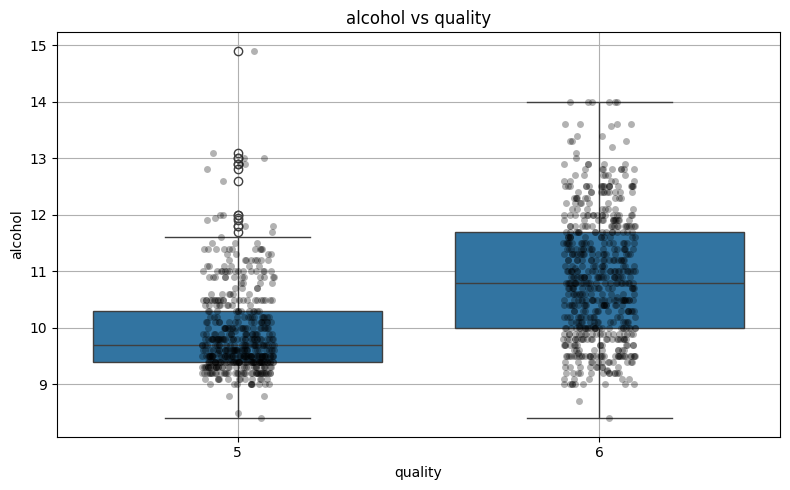


===== FEATURE: sulphates =====

Class 5
count    522.000000
mean       0.614195
std        0.171413
min        0.330000
25%        0.520000
50%        0.570000
75%        0.640000
max        2.000000
Name: sulphates, dtype: float64

Class 6
count    621.000000
mean       0.694283
std        0.160801
min        0.390000
25%        0.590000
50%        0.660000
75%        0.770000
max        1.950000
Name: sulphates, dtype: float64

===== SHAPIRO-WILK =====
Class 5: stat=0.7263, p=2.2332e-28
Class 6: stat=0.8459, p=4.2600e-24

===== LEVENE =====
stat=2.3423, p=1.2618e-01

===== WELCH T-TEST =====
stat=-8.0932, p=1.5549e-15

===== MANN-WHITNEY U =====
stat=94833.0000, p=1.0371e-33

===== CONFIDENCE INTERVAL =====
Mean difference: -0.0801
95% CI: [-0.0995, -0.0607]


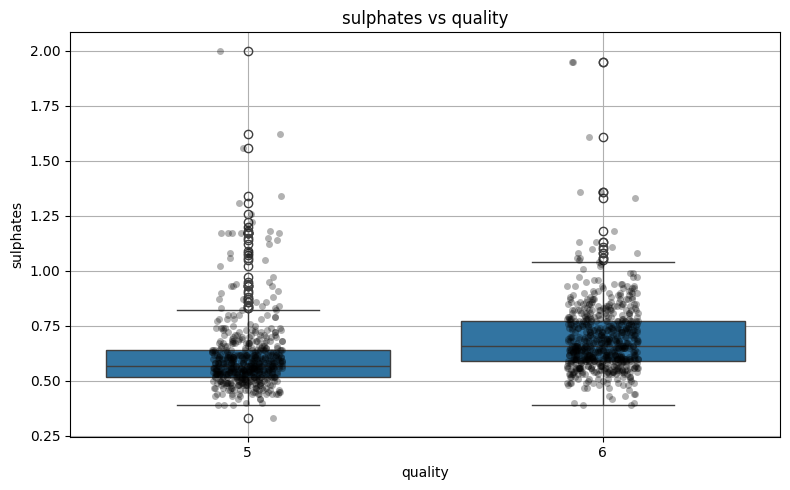


===== FEATURE: volatile acidity =====

Class 5
count    522.000000
mean       0.596121
std        0.179422
min        0.180000
25%        0.470000
50%        0.590000
75%        0.690000
max        1.580000
Name: volatile acidity, dtype: float64

Class 6
count    621.000000
mean       0.476884
std        0.160874
min        0.120000
25%        0.360000
50%        0.470000
75%        0.580000
max        1.040000
Name: volatile acidity, dtype: float64

===== SHAPIRO-WILK =====
Class 5: stat=0.9647, p=6.9830e-10
Class 6: stat=0.9798, p=1.5223e-07

===== LEVENE =====
stat=0.5698, p=4.5050e-01

===== WELCH T-TEST =====
stat=11.7290, p=5.9262e-30

===== MANN-WHITNEY U =====
stat=225110.0000, p=8.3563e-30

===== CONFIDENCE INTERVAL =====
Mean difference: 0.1192
95% CI: [0.0993, 0.1392]


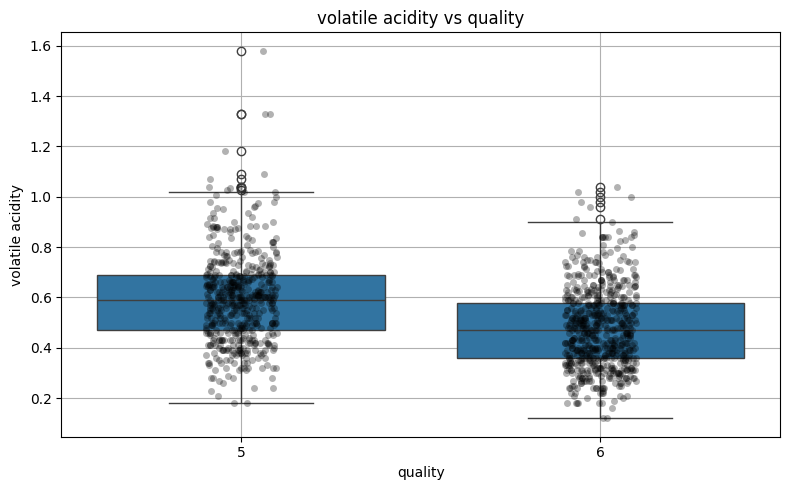

In [4]:
# TESTS

for feature in features:

    compare_feature_between_classes(
        df,
        feature=feature,
        class_a=5,
        class_b=6
    )

# Wyniki i wnioski:
- W celu przeprowadzenia testów statystycznych dla cech wykorzystano zbiór danych w trybie binarnym, dzieląc próbki na dwie grupy jakościowe: klasę 5 (522 próbki) oraz klasę 6 (621 próbek). Do szczegółowej analizy wyznaczono trzy kluczowe parametry: alcohol, sulphates oraz volatile acidity
- Przed wyborem właściwych testów weryfikujących różnice między grupami, sprawdzono założenia o normalności rozkładów (test Shapiro-Wilka) oraz jednorodności wariancji (test Levene'a) dla każdej z cech
- W przypadku wszystkich trzech cech test Shapiro-Wilka wykazał wartości p-value drastycznie mniejsze od poziomu istotności $\alpha = 0.05$. Oznacza to, że rozkłady tych cech w obu grupach jakościowych istotnie odbiegają od rozkładu normalnego, co wyklucza poprawność testów parametrycznych (Welch T-Test) i nakazuje oparcie ostatecznych wniosków na nieparametrycznym teście Manna-Whitneya U
- Dla cechy alcohol test Levene'a wykazał brak jednorodności wariancji ($p < 0.05$). Test Manna-Whitneya U zwrócił wartość $p = 5.3553 \times 10^{-54}$ (mniej niż $0.05$), co pozwala odrzucić hipotezę zerową o identyczności rozkładów. Analiza statystyk opisowych potwierdza, że wina wyższej jakości (klasy 6) charakteryzują się wyższą średnią zawartością alkoholu (10.88%) w porównaniu do klasy 5 (9.92%). Przedział ufności `[-1.0663, -0.8464]` potwierdza istotność tej różnicy
- Dla cechy sulphates test Levene'a nie dał podstaw do odrzucenia hipotezy o jednorodności wariancji ($p = 0.1262 > 0.05$). Z powodu braku normalności rozstrzygał jednak test Manna-Whitneya U, który osiągnął wartość $p = 1.0371 \times 10^{-33} < 0.05$. Odrzucono hipotezę zerową – wina klasy 6 posiadają statystycznie wyższy poziom siarczanów (średnia 0.69) niż wina klasy 5 (średnia 0.61)
- Dla cechy volatile acidity test Levene'a również potwierdził jednorodność wariancji ($p = 0.4505 > 0.05$). Test Manna-Whitneya U dał wynik $p = 8.3563 \times 10^{-30} < 0.05$, co wskazuje na występowanie istotnych różnic. W przypadku tego parametru kierunek zależności jest odwrotny – wina gorszej jakości (klasa 5) mają wyższe średnie volatile acidity (0.59) niż wina klasy 6 (0.47)
- Zarówno pomocniczo wywołany test parametryczny (Welch T-Test), jak i nieparametryczny test Manna-Whitneya U dały zgodne rezultaty we wszystkich trzech przypadkach, jednoznacznie potwierdzając, że alkohol, siarczany oraz lotna kwasowość to cechy o bardzo silnej wartości dyskryminacyjnej dla modeli klasyfikacyjnych